# Rents and the Last Walk to the Subway

**Mapping Systems — Assignment 04: Networks**<br>
**Study window:** July 2016 to June 2026  
**Geography:** 31 StreetEasy rent-neighborhood centers in Manhattan

## Research statement

How different is the straight-line distance from each Manhattan rent-neighborhood center to its **walking-network-nearest subway station** from the actual shortest pedestrian-network distance to that same station? How does that gap change the experience implied by a simple proximity map, and what non-causal relationship—if any—appears between walking distance and nominal median asking-rent growth?

The target station is selected by the pedestrian network, not by Euclidean proximity. Only after the target is fixed do I measure Euclidean distance to that same station. This makes the comparison like-for-like.

## tl;dr

The next cell is computed from the executed routes so that the summary cannot drift away from the data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

assignment_candidates = [Path.cwd(), Path.cwd() / "03_networks"]
ASSIGNMENT_DIR = next(
    candidate.resolve()
    for candidate in assignment_candidates
    if (candidate / "network_analysis.py").exists()
)
if str(ASSIGNMENT_DIR) not in sys.path:
    sys.path.insert(0, str(ASSIGNMENT_DIR))

from network_analysis import (
    plot_distance_comparison,
    plot_rent_relationship,
    plot_route_map,
    run_analysis,
)

analysis = run_analysis(
    ASSIGNMENT_DIR,
    refresh_osm=False,
    write_figures=False,
)
results = analysis["results"]
routes = analysis["routes"]
validation = analysis["validation"]
reachable = results[results["status"] == "reachable"].copy()

largest_detour = reachable.loc[reachable["detour_ratio"].idxmax()]
display(Markdown(
    f"""- All **{validation['reachable_count']} of {validation['result_neighborhood_count']}** neighborhood centers reach a Manhattan subway station in the graph.
- Median walking-network distance is **{validation['median_network_distance_m']:.0f} m**; the median detour ratio is **{validation['median_detour_ratio']:.2f}×**.
- **{validation['station_choice_changed_count']} of 31** network-nearest station choices differ from the station that looks nearest in Euclidean space.
- The largest detour is **{largest_detour['neighborhood']} → {largest_detour['target_station']}** at **{largest_detour['detour_ratio']:.2f}×** ({largest_detour['euclidean_distance_m']:.0f} m straight-line versus {largest_detour['network_distance_m']:.0f} m walking).
- Network distance and rent growth have a descriptive Spearman correlation of **{validation['spearman_network_distance_vs_growth']:.2f}**. This small, selected set of neighborhood centers cannot support a causal claim."""
))

- All **31 of 31** neighborhood centers reach a Manhattan subway station in the graph.
- Median walking-network distance is **393 m**; the median detour ratio is **1.50×**.
- **7 of 31** network-nearest station choices differ from the station that looks nearest in Euclidean space.
- The largest detour is **Midtown East → 51 St** at **1.88×** (350 m straight-line versus 659 m walking).
- Network distance and rent growth have a descriptive Spearman correlation of **0.37**. This small, selected set of neighborhood centers cannot support a causal claim.

## Context & methods

### What counts as a network?

The network is an undirected pedestrian graph. Intersections and path junctions are nodes; walkable OpenStreetMap segments are edges; each edge is weighted by its OSMnx length in meters. A rent-neighborhood center and each GTFS parent station are off-network observations, so both are snapped to the nearest graph node and their connector distances are included.

### Target-selection algorithm

1. Filter the 496-citywide GTFS parent-station points to those intersecting the Manhattan NTA boundary.
2. Snap the 31 neighborhood centers and Manhattan stations to a real OSMnx walking graph.
3. Temporarily connect all station nodes to a super-node. Each connection is weighted by the station-to-network snap distance.
4. Run NetworkX Dijkstra from each neighborhood node to the super-node using `length`.
5. The penultimate node identifies the station with minimum **network** distance. Add the origin snap connector.
6. Project the original origin and that same selected station to EPSG:2263 and measure their Euclidean distance.

### Key assumptions

- A StreetEasy neighborhood center is a representation point, not every resident's home.
- A GTFS parent-station coordinate is a station reference point, not a specific entrance.
- Walking distance includes mapped paths and two straight snap connectors; it does not include crossing delay, stairs, slope, crowding, safety, or temporary closures.
- Asking rent describes advertised listings, not the rent currently paid by all tenants. Growth is nominal and not inflation-adjusted.
- Any rent/access association is descriptive. There is no causal design or control for income, housing supply, zoning, station service, or neighborhood change.

## Data

In [2]:
input_checks = pd.Series(analysis["inputs"]["input_checks"], name="observed")
display(input_checks.to_frame())

rent_preview = results[[
    "neighborhood", "baseline_rent_usd", "latest_rent_usd", "growth_pct"
]].head(8)
display(rent_preview.style.format({
    "baseline_rent_usd": "${:,.0f}",
    "latest_rent_usd": "${:,.0f}",
    "growth_pct": "{:.1f}%",
}))

,observed
rent_neighborhoods,31
rent_months_per_neighborhood,120
rent_start,2016-07
rent_end,2026-06
rent_missing_values,0
subway_stations_all_nyc,496
subway_stations_in_manhattan,152
manhattan_nta_features,38
analysis_crs,EPSG:4326 for interchange; EPSG:2263 for plana...


,neighborhood,baseline_rent_usd,latest_rent_usd,growth_pct
0,Battery Park City,"$4,750","$5,758",21.2%
1,Central Harlem,"$2,500","$3,600",44.0%
2,Central Park South,"$7,400","$12,500",68.9%
3,Chelsea,"$4,200","$6,131",46.0%
4,Chinatown,"$2,800","$4,380",56.4%
5,East Harlem,"$2,450","$3,250",32.7%
6,East Village,"$3,300","$5,250",59.1%
7,Financial District,"$3,695","$4,925",33.3%


The rent input has a complete 120-month series for every neighborhood. Only the first and last months define `growth_pct`; the monthly histories are retained in the source file. Station and NTA layers are WGS84 GeoJSON. EPSG:2263 is used only when a planar straight-line distance is needed.

## Creating the pedestrian network

In [3]:
graph_summary = {
    "nodes": analysis["graph"].number_of_nodes(),
    "edges": analysis["graph"].number_of_edges(),
    "directed": analysis["graph"].is_directed(),
    "crs": analysis["graph"].graph.get("crs"),
    "network_type": "walk",
    "boundary": "Manhattan NTAs + 1,500 m buffer",
    "source_mode": analysis["graph_manifest"].get("source", {}).get(
        "mode", analysis["graph_manifest"].get("loaded_from")
    ),
}
display(pd.Series(graph_summary, name="network snapshot").to_frame())

,network snapshot
nodes,59213
edges,90814
directed,False
crs,epsg:4326
network_type,walk
boundary,"Manhattan NTAs + 1,500 m buffer"
source_mode,verified_workspace_cache


The executed version uses the bounded, hash-manifested OSMnx snapshot in `data/network_snapshot/`. It was derived from the verified NYC TIME FIELD OSM walk graph retrieved on 2026-07-27. This fixes the network for reproducibility. `python build_assignment.py --refresh-osm` explicitly attempts a fresh Overpass download; if that service fails, the build records the error and falls back to the verified graph instead of inventing distances.

## Nodes, routes, and measured distances

In [4]:
route_table = reachable[[
    "neighborhood",
    "target_station",
    "target_routes",
    "euclidean_distance_m",
    "network_distance_m",
    "detour_ratio",
    "estimated_walk_minutes",
    "growth_pct",
    "target_differs_from_euclidean_nearest",
]].sort_values("detour_ratio", ascending=False)

display(route_table.head(12).style.format({
    "euclidean_distance_m": "{:.0f}",
    "network_distance_m": "{:.0f}",
    "detour_ratio": "{:.2f}×",
    "estimated_walk_minutes": "{:.1f}",
    "growth_pct": "{:.1f}%",
}))

,neighborhood,target_station,target_routes,euclidean_distance_m,network_distance_m,detour_ratio,estimated_walk_minutes,growth_pct,target_differs_from_euclidean_nearest
17,Midtown East,51 St,4 6 6X,350,659,1.88×,8.2,49.9%,False
14,Lower East Side,Delancey St-Essex St,J M Z,191,350,1.83×,4.4,50.4%,True
26,Upper East Side,77 St,4 6 6X,327,591,1.81×,7.4,47.7%,False
18,Midtown South,33 St,4 6 6X,408,706,1.73×,8.8,38.7%,True
8,Flatiron,23 St,N Q R W,84,141,1.68×,1.8,31.9%,False
24,Stuyvesant Town/PCV,1 Av,L,433,725,1.68×,9.1,51.8%,False
1,Central Harlem,125 St,2 3,441,728,1.65×,9.1,44.0%,True
11,Hamilton Heights,145 St,1,75,122,1.63×,1.5,41.3%,False
27,Upper West Side,86 St,1 2,183,295,1.62×,3.7,37.1%,False
21,Nolita,Spring St,4 6 6X,164,260,1.59×,3.3,48.7%,False


## Map: shortest walking routes

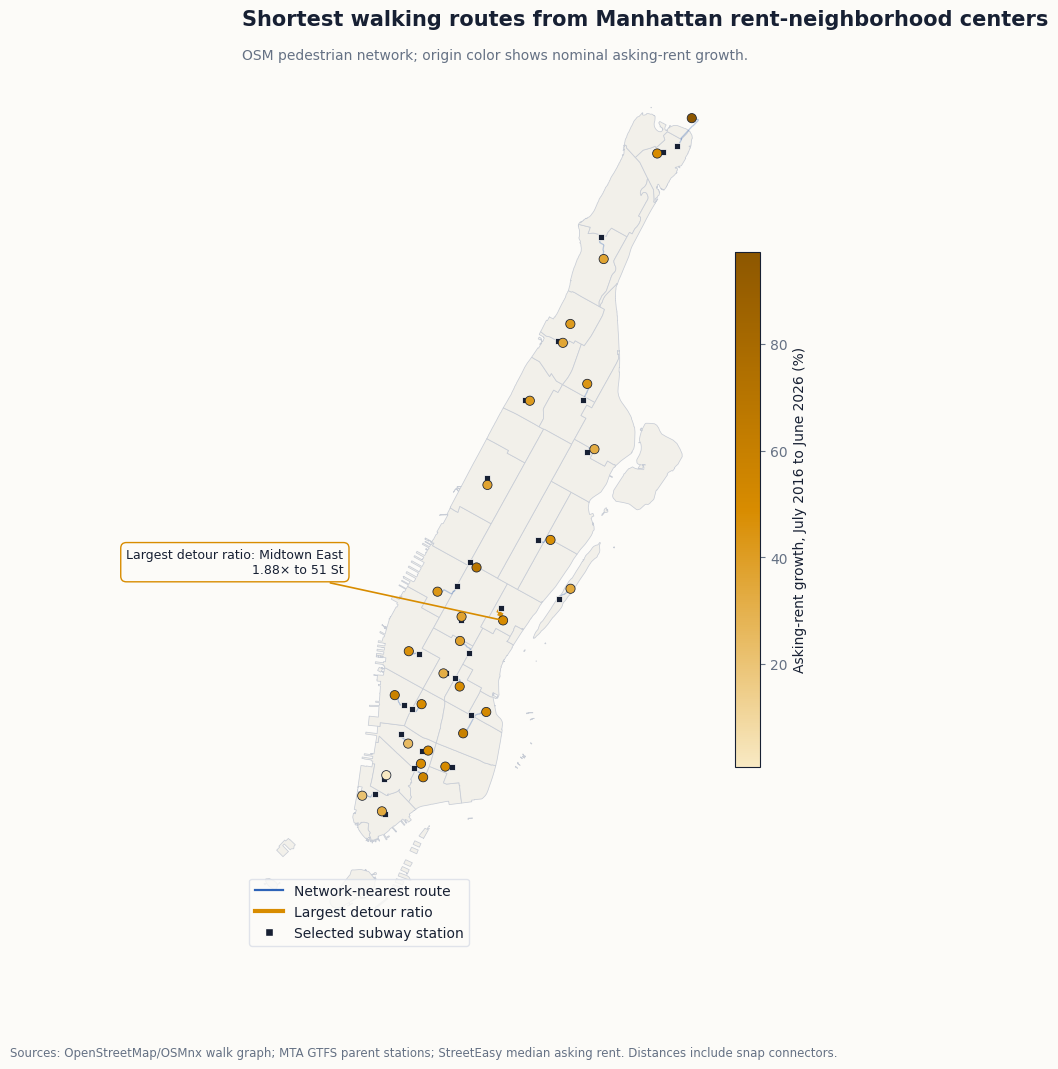

In [5]:
route_figure = plot_route_map(
    analysis["paths"],
    analysis["inputs"]["nta"],
    results,
    routes,
    analysis["stations"],
    close=False,
)
plt.show()
plt.close(route_figure["figure"])

The map makes two abstractions visible at once: each origin is a single neighborhood reference point, and each route ends at a parent-station point. The highlighted route has the largest ratio between network and straight-line distance. Streets, crossings, parks, blocks, and access points make a visually short gap longer in practice.

## Chart: Euclidean distance versus network distance

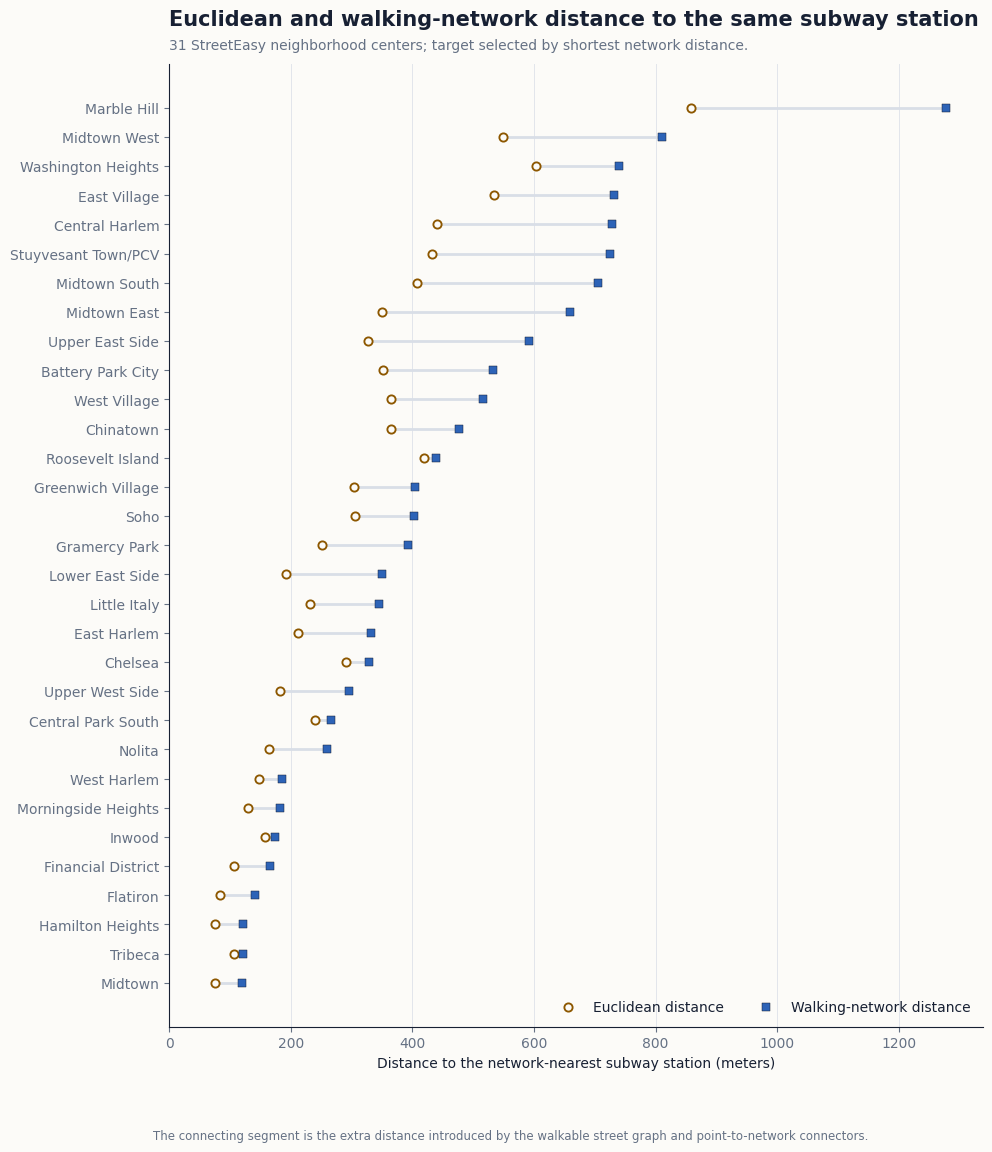

In [6]:
distance_figure = plot_distance_comparison(
    analysis["paths"],
    results,
    close=False,
)
plt.show()
plt.close(distance_figure["figure"])

The orange circle and blue square always refer to the **same station**. The connector between them is therefore not a station-choice artifact: it is the distance added by moving through the mapped walkable graph and by connecting each observation to that graph. A straight line can cross buildings, blocks, park edges, rail infrastructure, or inaccessible station sides; a pedestrian route cannot.

## Chart: distance and asking-rent growth

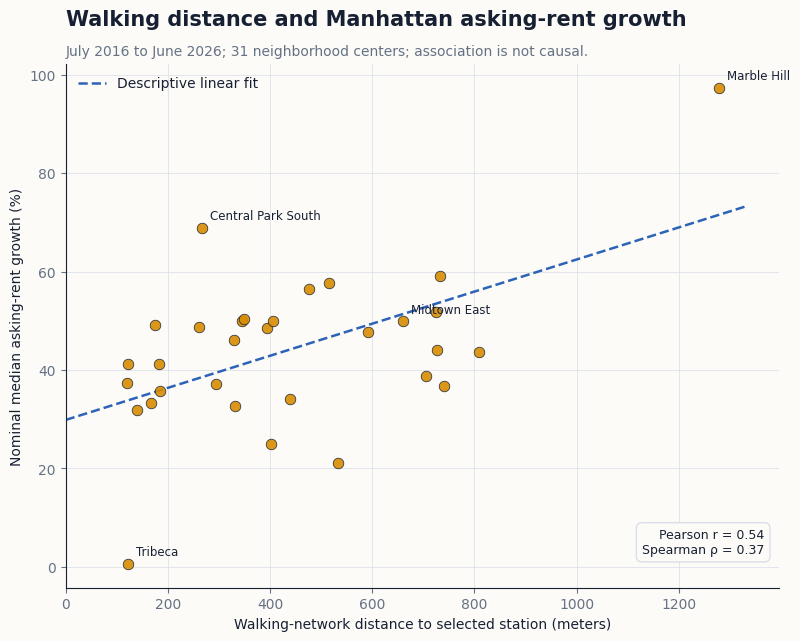

In [7]:
rent_figure = plot_rent_relationship(
    analysis["paths"],
    results,
    validation,
    close=False,
)
plt.show()
plt.close(rent_figure["figure"])

The fitted line is a visual description, not an explanatory model. With only 31 hand-positioned neighborhood centers, a single high-growth and comparatively distant observation can influence the pattern. Rent growth may covary with many omitted factors, while this analysis measures only one point per named market area and one station-access route.

## Checks

In [8]:
check_table = pd.Series({
    "31 unique results": validation["result_neighborhood_count"] == 31
        and validation["duplicate_neighborhood_ids"] == 0,
    "all origins reachable": validation["unreachable_count"] == 0,
    "one route per reachable origin": validation["route_feature_count"]
        == validation["reachable_count"],
    "network ≥ Euclidean (5 m tolerance)":
        validation["network_shorter_than_euclidean_violations"] == 0,
    "route weight reconstructed":
        validation["max_route_reconstruction_error_m"] < 1e-6,
    "all automated checks": validation["all_checks_pass"],
}, name="passed")
display(check_table.to_frame())

display(Markdown(
    f"Unreachable handling is explicit: an origin without a station in its connected "
    f"component receives `status='unreachable'` and null distance fields, and is excluded "
    f"from correlations and maps. In this run the unreachable count is "
    f"**{validation['unreachable_count']}**."
))

,passed
31 unique results,True
all origins reachable,True
one route per reachable origin,True
network ≥ Euclidean (5 m tolerance),True
route weight reconstructed,True
all automated checks,True


Unreachable handling is explicit: an origin without a station in its connected component receives `status='unreachable'` and null distance fields, and is excluded from correlations and maps. In this run the unreachable count is **0**.

## Takeaways and reflection

In [9]:
changed_share = validation["station_choice_changed_count"] / 31
display(Markdown(
    f"""1. **Euclidean proximity is an incomplete experience of access.** The median route is {validation['median_detour_ratio']:.2f} times the direct distance, even after choosing the station that is best on the network.
2. **The network can change the destination, not only the distance.** In {validation['station_choice_changed_count']} neighborhoods ({changed_share:.0%}), the network-selected station is not the Euclidean-nearest station.
3. **Access and rent growth should not be collapsed into one story.** The observed Spearman association is {validation['spearman_network_distance_vs_growth']:.2f}, but the neighborhood centers, time-varying housing market, station service, and omitted social and land-use conditions prevent causal interpretation.
4. **A next iteration should start from residences and station entrances.** Sampling many residential points per neighborhood, routing to actual accessible entrances, and adding travel time, slope, crossings, and service frequency would describe lived access better than one centroid-to-parent-station route."""
))

1. **Euclidean proximity is an incomplete experience of access.** The median route is 1.50 times the direct distance, even after choosing the station that is best on the network.
2. **The network can change the destination, not only the distance.** In 7 neighborhoods (23%), the network-selected station is not the Euclidean-nearest station.
3. **Access and rent growth should not be collapsed into one story.** The observed Spearman association is 0.37, but the neighborhood centers, time-varying housing market, station service, and omitted social and land-use conditions prevent causal interpretation.
4. **A next iteration should start from residences and station entrances.** Sampling many residential points per neighborhood, routing to actual accessible entrances, and adding travel time, slope, crossings, and service frequency would describe lived access better than one centroid-to-parent-station route.

## Sources and reproducibility

- **StreetEasy:** [Data Dashboard](https://streeteasy.com/blog/data-dashboard/) / Master Report, median asking rent for all rentals. Local frozen analysis window: 2016-07 through 2026-06.
- **Pedestrian network:** [OpenStreetMap](https://www.openstreetmap.org/copyright), downloaded and simplified with OSMnx 2.1.0; bounded graph hash and provenance are recorded in `data/network_snapshot/manhattan_walk_manifest.json`.
- **Subway stations:** [MTA New York City Transit GTFS](https://web.mta.info/developers/data/nyct/subway/google_transit.zip), parent-station points prepared by the NYC TIME FIELD pipeline.
- **Boundary:** NYC Department of City Planning 2020 Neighborhood Tabulation Areas, Manhattan subset.

Run the whole assignment with:

```bash
python build_assignment.py
```

Generated tables, GeoJSON routes, validation JSON, and the executed Notebook are written inside this assignment directory. Maps and charts are rendered directly by the Notebook cells rather than loaded from saved image files.